In [1]:
from mdcrow import MDCrow
from langchain.callbacks import get_openai_callback
from datetime import datetime
import os 
import traceback

In [2]:
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../'))
sys.path.append(parent_dir)
from robustness_prompts import get_prompt # noqa: E402

prompt_8_natural = get_prompt("natural", 8)

prompt_8_natural

'Simulate 1LYZ for 1ps at 300 K and for 1ps at 400K. Report the secondary structure assignments of the downloaded PDB structure and any known binding or active sites. Compute the RMSD, SASA, and radius of gyration of the 300K simulation.'

In [3]:
llm_model = "together/meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo"
tools = "all"

In [4]:
agent = MDCrow(
    agent_type="Structured", 
    model=llm_model, 
    top_k_tools=tools, 
    use_memory=False,
    streaming=False,
    verbose=True,
)
with get_openai_callback() as cb:
    chat_start = datetime.now()
    try:
        response = agent.run(prompt_8_natural, callbacks=[cb])
        print(response)
    except Exception as e:
        exc_type, exc_value, exc_traceback = sys.exc_info()
        print(f'{type(e).__name__}:{e}')
        print("".join(traceback.format_exception(exc_type, exc_value, exc_traceback)))
    chat_end = datetime.now()
    total_runtime = (chat_end - chat_start).total_seconds()
    print(cb)
    print(f"Total runtime: {total_runtime:.2f}s")



> Entering new AgentExecutor chain...


Thought: To solve this problem, we need to first download the PDB structure of 1LYZ, then simulate it at 300 K and 400 K for 1 ps each. After that, we can compute the secondary structure assignments, RMSD, SASA, and radius of gyration of the 300 K simulation. We also need to find any known binding or active sites.

Action:
```
{
  "action": "PDBFileDownloader",
  "action_input": "1LYZ"
}
```PDB file found with this ID: 1LYZ

Observation: Succeeded. Downloaded the PDB file:1LYZ_215102
Thought:

Thought: Now that we have the PDB file, we can simulate it at 300 K and 400 K for 1 ps each. We will use the SetUpandRunFunction tool to set up and run the simulations.

Action:
```
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1LYZ_215102",
    "forcefield_files": ["amber14sb.xml", "tip3p.xml"],
    "save": true,
    "system_params": {
      "nonbondedMethod": "PME",
      "nonbondedCutoff": "1.0 * nanometers",
      "ewaldErrorTolerance": 0.0005,
      "constraints": "HBonds",
      "rigidWater": true,
      "constraintTolerance": 0.00001,
      "solvate": true
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "300 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds",
      "Pressure": "1.0 * bar"
    },
    "simulation_params": {
      "Ensemble": "NPT",
      "Number of Steps": 500,
      "record_interval_steps": 100,
      "record_params": ["step", "potentialEnergy", "tem

Thought: Now that we have the PDB file, we can simulate it at 300 K and 400 K for 1 ps each. We will use the SetUpandRunFunction tool to set up and run the simulations. We need to correct the forcefield files to match the available options.

Action:
```
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1LYZ_215102",
    "forcefield_files": ["amber14/protein.ff14SB.xml", "amber14/tip3p.xml"],
    "save": true,
    "system_params": {
      "nonbondedMethod": "PME",
      "nonbondedCutoff": "1.0 * nanometers",
      "ewaldErrorTolerance": 0.0005,
      "constraints": "HBonds",
      "rigidWater": true,
      "constraintTolerance": 0.00001,
      "solvate": true
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "300 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds",
      "Pressure": "1.0 * bar"
    },
    "simulation_params": {
      "Ensemble": "NPT",
      "Number of Steps": 500

Error adding solvent ValueError – No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#template
Residue code: LYS
Residue code not in solvent list. Adding forcefield                         not supported.

Observation: Failed. No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#templateThis were the inputs {'pdb_id': '1LYZ_215102', 'forcefield_files': ['amber14/protein.ff14SB.xml', 'amber14/tip3p.xml'], 'save': True, 'system_params': {'nonbondedMethod': 'PME', 'nonbondedCutoff': '1.0 * nanometers', 'ewaldErrorTolerance': 0.0005, 'constraints': 'HBonds', 'rigidWater': True, 'constraintTolerance': 1e-05, 'solvate': True}, 'integrator_params': {'integrator_type': 'LangevinMiddle', 'Temperature': '300 * kelvin

...

The primary accession number provided does not match any entry in the data, using the first entry instead.

Observation: []
Thought:

Thought: Now that we have the secondary structure assignments, RMSD, SASA, and radius of gyration of the 300 K simulation, we can find any known active sites.

Action:
```
{
  "action": "GetActiveSites",
  "action_input": {
    "query": "1LYZ",
    "primary_accession": "P00722"
  }
}
```

The primary accession number provided does not match any entry in the data, using the first entry instead.

Observation: [{'start': 53, 'start_modifier': 'EXACT', 'end': 53, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}, {'start': 71, 'start_modifier': 'EXACT', 'end': 71, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}]
Thought:

Action:
```
{
  "action": "Final Answer",
  "action_input": "The secondary structure assignments of the downloaded PDB structure are: 801 residues in helix, 200 residues in strand, 934 residues in coil, and 101865 residues not assigned, not a protein residue. The RMSD of the 300 K simulation is saved to csv with file ID rmsd_1LYZ and the plot is saved with plot ID fig0_221334. The SASA values of the 300 K simulation are computed and saved with File ID sasa_1LYZ and the plot is saved with plot ID fig0_221442. The radius of gyration of the 300 K simulation is saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_28/figures/radii_of_gyration_rec0_215121.csv with id rgy_rec0_215121 and the plot is saved as: FIG_rgy_rec0_215121_20251222_221445.png with plot ID fig0_221445. The average radius of gyration is 3.40 nm. There are no known binding sites for 1LYZ. The known active sites for 1LYZ are: 53 and 71."
}
```

> Finished chain.
({'input': '\n    You are an expert molecular dynamics s

<Figure size 640x480 with 0 Axes>

In [3]:
registry = agent.path_registry
print(registry.list_path_names_and_descriptions().replace(",", "\n"))

Files found in registry: 1LYZ_215102: PDB file downloaded from RSCB
 PDBFile ID: 1LYZ_215102
 1LYZ_215112: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added and nonstandard residues replaced. 
 top_sim0_215116: Initial positions for simulation sim0_215116
 sim0_215116: Basic Simulation of Protein 1LYZ_215112
 rec0_215121: Simulation trajectory for protein 1LYZ_215112 and simulation sim0_215116
 rec1_215121: Simulation state log for protein 1LYZ_215112 and simulation sim0_215116
 rec2_215121: Simulation pdb frames for protein 1LYZ_215112 and simulation sim0_215116
 top_sim0_220159: Initial positions for simulation sim0_220159
 sim0_220159: Basic Simulation of Protein 1LYZ_215112
 rec0_220204: Simulation trajectory for protein 1LYZ_215112 and simulation sim0_220159
 rec1_220204: Simulation state log for protein 1LYZ_215112 and simulation sim0_220159
 rec2_220204: Simulation pdb frames for protein 1LYZ_2151

In [4]:
# make sure pdb was downloaded
assert os.path.exists(registry.get_mapped_path("1LYZ_215102"))

In [5]:
# make sure dssp was computed correctly
from mdcrow.tools.base_tools import ComputeDSSP

dssp = ComputeDSSP(registry)
dssp._run(traj_file= "1LYZ_215102", target_frames="first")

"{'residues in helix': 50, 'residues in strand': 14, 'residues in coil': 65, 'residues not assigned, not a protein residue': 101}"

In [9]:
# make sure the sites were found
from mdcrow.tools.base_tools import GetAllKnownSites

get_all_known_sites = GetAllKnownSites()
get_all_known_sites._run(query="1LYZ", primary_accession="")

"Active Sites: [{'start': 53, 'start_modifier': 'EXACT', 'end': 53, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}, {'start': 71, 'start_modifier': 'EXACT', 'end': 71, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}]\nNo known binding sites.\nNo other relevant sites."

In [13]:
# make sure trajectory and topology exist
traj_path_1 = registry.get_mapped_path("rec0_215121")
top_path_1 = registry.get_mapped_path("top_sim0_215116")


assert os.path.exists(traj_path_1)
assert os.path.exists(top_path_1)

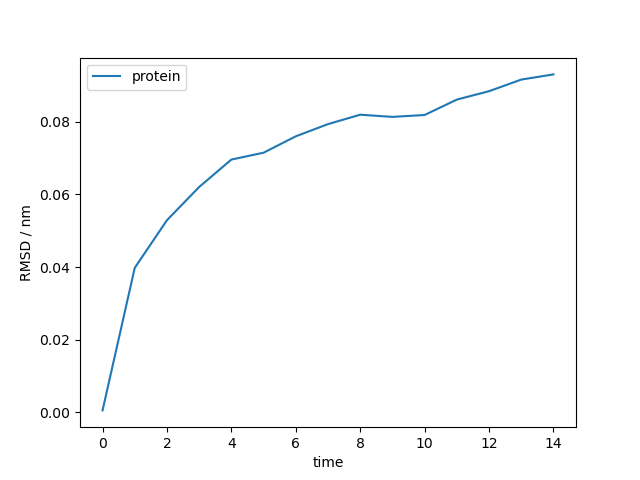

In [7]:
# make sure rmsd plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_221334'))

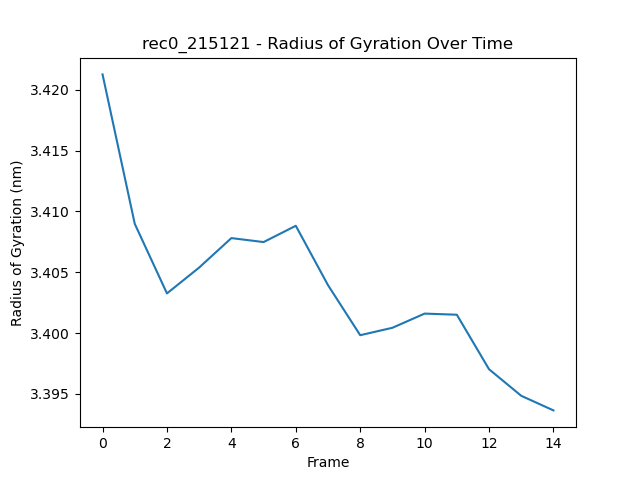

In [10]:
# make sure rgy plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_221445'))

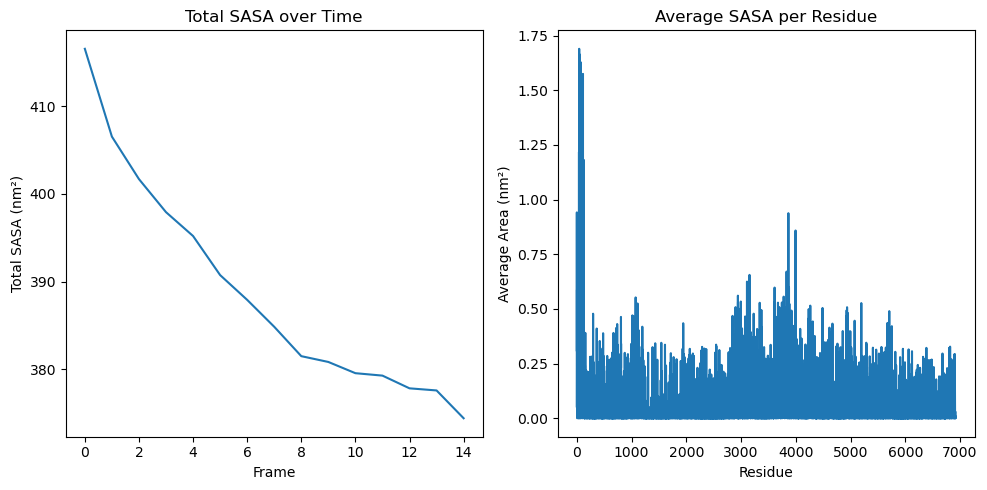

In [9]:
# make sure sasa plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_221442'))

In [12]:
# make sure trajectory and topology exist (sim2)
traj_path_2 = registry.get_mapped_path("rec0_220204")
top_path_2 = registry.get_mapped_path("top_sim0_220159")

assert os.path.exists(traj_path_2)
assert os.path.exists(top_path_2)

In [14]:
#verify the total cost
def calculate_llm_cost(input_tokens, output_tokens, model):
    if model == 'meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo':
        model = "llama-v3p1-70b-instruct"
    elif model == 'meta-llama/Meta-Llama-3.1-405B-Instruct-Turbo':
        model = "llama-v3p1-405b-instruct"
    pricing_2024 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 5/1e6, "output": 15/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
        "claude-3-opus": {"input": 15/1e6, "output": 75/1e6},
        "claude-3.5-sonnet": {"input": 3/1e6, "output": 15/1e6},
    }
    pricing_2025 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 2.5/1e6, "output": 10/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
    }
    
    prices = pricing_2025[model]
    cost = (input_tokens * prices["input"]) + (output_tokens * prices["output"])
    return round(cost, 6)

llm_cost = calculate_llm_cost(128241, 2463, 'meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo')
print('Input tokens:',128241)
print('Output tokens:',2463)
print('LLM costs: $',llm_cost)

Input tokens: 128241
Output tokens: 2463
LLM costs: $ 0.117634
